In [1]:
"""
Korelasyon Analizi - Isı Haritası (Heatmap)
============================================
Ev Fiyat Tahmin Projesi - Gerçek Veri Seti
King County (Seattle) ev satış verileri

Kullanım:
    python korelasyon_analizi.py
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

# ---- Türkçe karakter desteği ----
matplotlib.rcParams["font.family"] = "DejaVu Sans"

In [2]:
df = pd.read_csv("ayiklanmis_Data/data.csv")

print(f"Veri seti boyutu: {df.shape[0]} satır, {df.shape[1]} sütun")
print(f"Sütunlar: {list(df.columns)}\n")

Veri seti boyutu: 4600 satır, 18 sütun
Sütunlar: ['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city', 'statezip', 'country']



In [3]:
df["house_age"] = 2015 - df["yr_built"]

In [4]:
sayisal_sutunlar = [
    "price",
    "sqft_living",
    "bedrooms",
    "bathrooms",
    "floors",
    "waterfront",
    "view",
    "condition",
    "sqft_above",
    "sqft_basement",
    "house_age",
    "yr_renovated",
]

sayisal_df = df[sayisal_sutunlar]

In [5]:
korelasyon = sayisal_df.corr()

# Konsola price korelasyonlarını yazdır (hızlı kontrol)
print("=" * 50)
print("PRICE ile Korelasyonlar (büyükten küçüğe):")
print("=" * 50)
price_kor = korelasyon["price"].drop("price").sort_values(ascending=False)
for ozellik, deger in price_kor.items():
    isaret = "🟢" if abs(deger) > 0.5 else "🟡" if abs(deger) > 0.3 else "⚪"
    print(f"  {isaret} {ozellik:20s}  {deger:+.4f}")
print()

PRICE ile Korelasyonlar (büyükten küçüğe):
  🟡 sqft_living           +0.4304
  🟡 sqft_above            +0.3676
  🟡 bathrooms             +0.3271
  ⚪ view                  +0.2285
  ⚪ sqft_basement         +0.2104
  ⚪ bedrooms              +0.2003
  ⚪ floors                +0.1515
  ⚪ waterfront            +0.1356
  ⚪ condition             +0.0349
  ⚪ house_age             -0.0219
  ⚪ yr_renovated          -0.0288



[None, None, None, None, None, None, None, None, None]

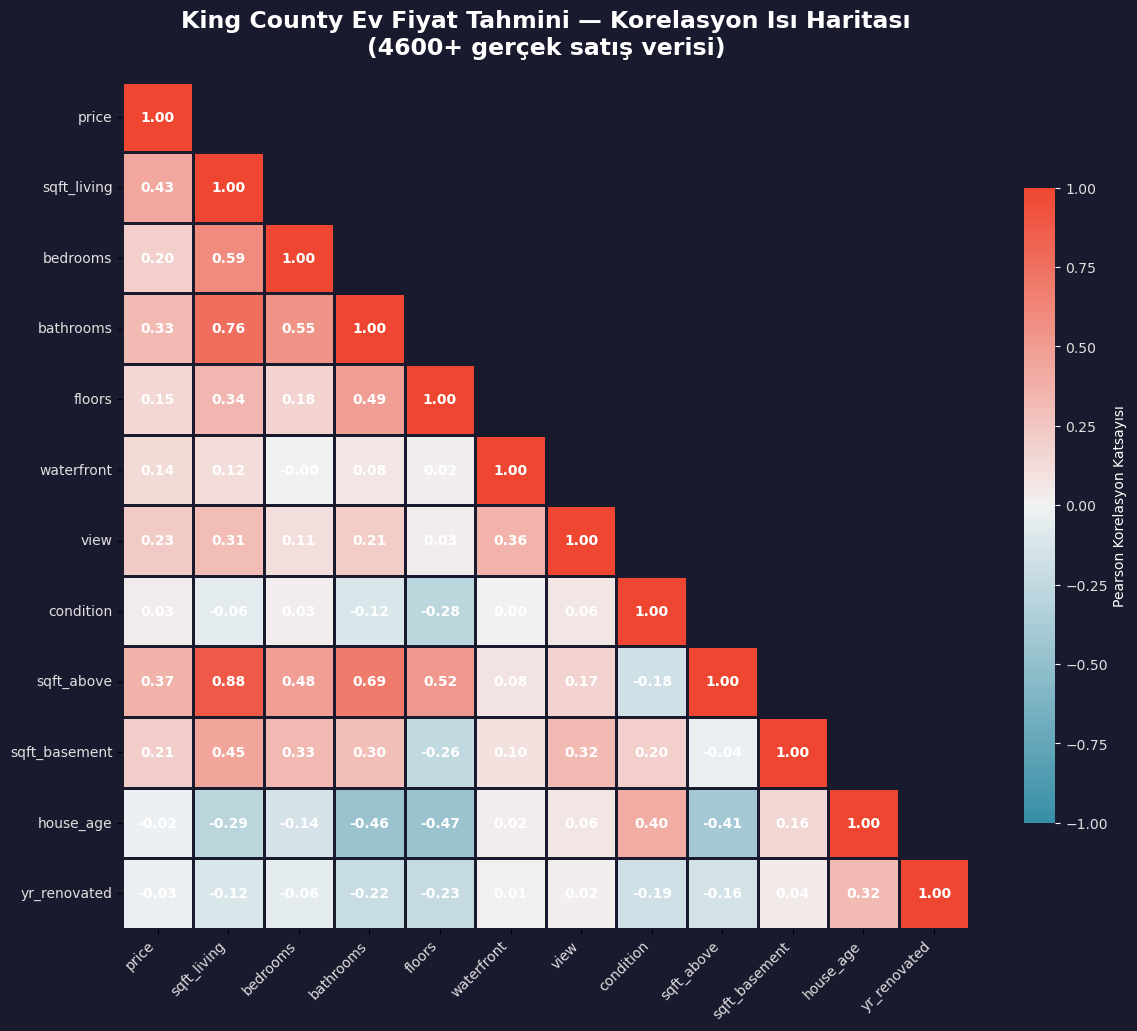

In [6]:
# Üst üçgen maskesi (tekrar eden bilgiyi gizle — matris simetriktir)
maske = np.triu(np.ones_like(korelasyon, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(14, 11))

# Koyu arka plan
fig.patch.set_facecolor("#1a1a2e")
ax.set_facecolor("#1a1a2e")

# Renk paleti: negatif → mavi, sıfır → koyu, pozitif → kırmızı
cmap = sns.diverging_palette(220, 15, s=85, l=55, as_cmap=True)

sns.heatmap(
    korelasyon,
    mask=maske,
    annot=True,                      # Korelasyon değerlerini hücre içine yaz
    fmt=".2f",                       # 2 ondalık basamak
    cmap=cmap,
    vmin=-1, vmax=1,                 # Sabit ölçek (-1 ile +1)
    center=0,
    square=True,
    linewidths=2,
    linecolor="#1a1a2e",
    cbar_kws={
        "shrink": 0.75,
        "label": "Pearson Korelasyon Katsayısı",
    },
    annot_kws={
        "size": 10,
        "weight": "bold",
        "color": "white",
    },
    ax=ax,
)

# Başlık
ax.set_title(
    "King County Ev Fiyat Tahmini — Korelasyon Isı Haritası\n(4600+ gerçek satış verisi)",
    fontsize=17,
    fontweight="bold",
    color="white",
    pad=20,
)

# Etiketler
ax.set_xticklabels(ax.get_xticklabels(), fontsize=10, color="#e0e0e0", rotation=45, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), fontsize=10, color="#e0e0e0", rotation=0)

# Colorbar yazı rengi
cbar = ax.collections[0].colorbar
cbar.ax.yaxis.set_tick_params(color="white")
cbar.ax.yaxis.label.set_color("white")
plt.setp(cbar.ax.yaxis.get_ticklabels(), color="#e0e0e0")



In [7]:
uyarilar = []
gucliler = []

for i in range(len(korelasyon.columns)):
    for j in range(i + 1, len(korelasyon.columns)):
        col_i = korelasyon.columns[i]
        col_j = korelasyon.columns[j]
        deger = korelasyon.iloc[i, j]

        # Multicollinearity uyarısı (hedef hariç özellikler arası)
        if abs(deger) > 0.8 and col_i != "price" and col_j != "price":
            uyarilar.append(f"⚠  {col_i} ↔ {col_j}: {deger:+.2f}  (Multicollinearity riski!)")

        # Güçlü tahmin ediciler (price ile ilişki)
        if abs(deger) > 0.4 and (col_i == "price" or col_j == "price"):
            gucliler.append(f"✓  {col_i} ↔ {col_j}: {deger:+.2f}  (Güçlü tahmin edici)")

satirlar = []
if gucliler:
    satirlar.append("Güçlü Tahmin Ediciler:")
    satirlar.extend(gucliler)
if uyarilar:
    satirlar.append("\nMulticollinearity Uyarıları:")
    satirlar.extend(uyarilar)
if not satirlar:
    satirlar.append("Belirgin yüksek korelasyon tespit edilmedi.")

yorum_metni = "\n".join(satirlar)

fig.text(
    0.02, -0.02,
    yorum_metni,
    fontsize=9,
    color="#a0d2db",
    family="monospace",
    verticalalignment="top",
    bbox=dict(boxstyle="round,pad=0.6", facecolor="#16213e", edgecolor="#a0d2db", alpha=0.9),
)

plt.tight_layout()
plt.savefig("output/korelasyon_heatmap.png", dpi=200, bbox_inches="tight", facecolor=fig.get_facecolor())

print("✅ Heatmap kaydedildi → korelasyon_heatmap.png")
print("\n" + yorum_metni)


✅ Heatmap kaydedildi → korelasyon_heatmap.png

Güçlü Tahmin Ediciler:
✓  price ↔ sqft_living: +0.43  (Güçlü tahmin edici)

Multicollinearity Uyarıları:
⚠  sqft_living ↔ sqft_above: +0.88  (Multicollinearity riski!)


<Figure size 640x480 with 0 Axes>

<Axes: xlabel='bedrooms', ylabel='price'>

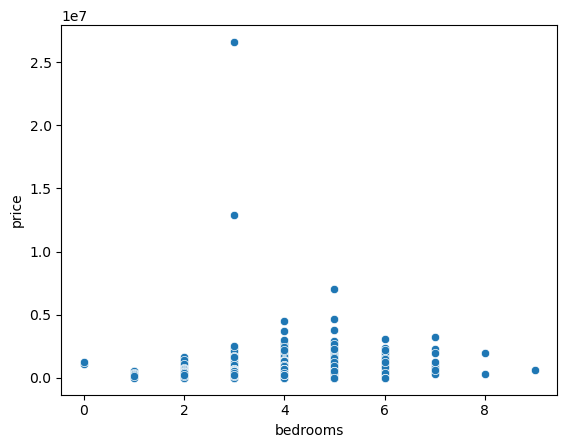

In [8]:
sns.scatterplot(x="bedrooms", y="price", data=df)

<Axes: xlabel='bedrooms', ylabel='price'>

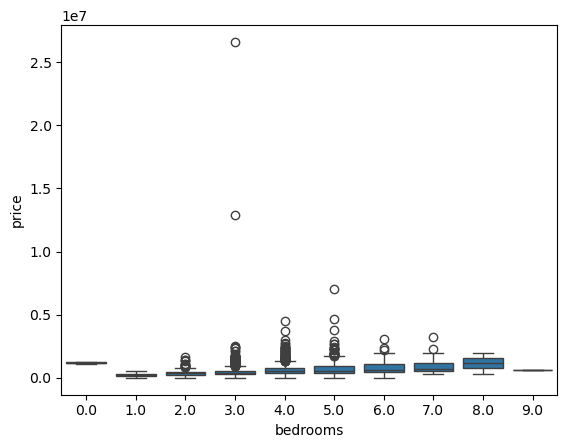

In [9]:
sns.boxplot(x="bedrooms", y="price", data=df)

<Axes: xlabel='bedrooms', ylabel='price'>

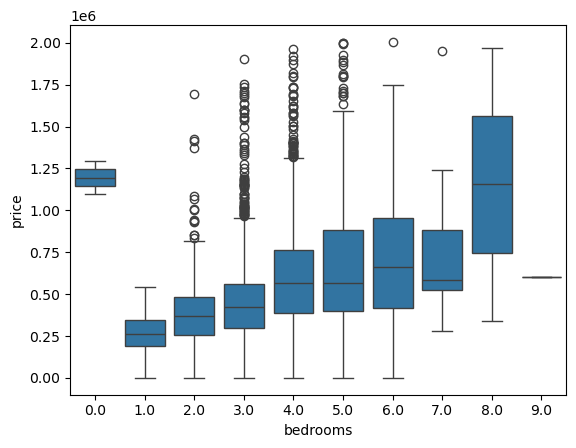

In [17]:

limit = df["price"].quantile(0.99)
df_temiz = df[df["price"] < limit]


sns.boxplot(x="bedrooms", y="price", data=df_temiz)

In [18]:
# Gruplama — basit ve etkili
df["bedrooms_grouped"] = df["bedrooms"].clip(upper=6)

<Axes: xlabel='bedrooms_grouped', ylabel='price'>

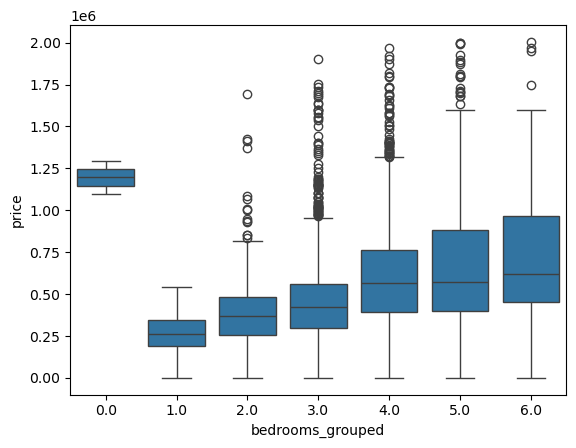

In [19]:

sns.boxplot(x="bedrooms_grouped", y="price", data=df_temiz)

In [ ]:
#
#df_temiz["bedrooms"].value_counts()    # Her kategoride kaç örnek var?
df_temiz["condition"].value_counts()
df_temiz["view"].value_counts()


view
0    4140
2     205
3     116
4      70
1      69
Name: count, dtype: int64

In [ ]:
"""
YAPILMASI GEREKENLER:


"""
# 1) Genel bakış
df.shape                    # Kaç satır, kaç sütun?
df.dtypes                   # Hangi sütun ne tip?
df.describe()               # Min, max, mean, std — aykırı değerleri yakala

# 2) Eksik veri kontrolü
df.isnull().sum()           # Hangi sütunda kaç null var?

# 3) Kategorik/düşük kardinaliteli sütunlar için dağılım
df["bedrooms"].value_counts()    # Her kategoride kaç örnek var?
df["condition"].value_counts()
df["view"].value_counts()

# 4) Hedef değişkenin dağılımı
df["price"].hist(bins=50)        # Çarpık mı, normal mi?



""" 

Burada Öğrendiğin Genel Kural
DurumYöntemAz sayıda anlamlı kategori (condition: 1-5)One-Hot Encoding
Çok sayıda seyrek kategori (yr_renovated: 50+ farklı yıl)Binary veya sayısal dönüşüm
Ordinal sıralama var (view: 0→4 = kötü→iyi)Olduğu gibi bırak (sayısal)
Çok yüksek kardinalite (city: 40+ şehir)Target encoding veya gruplama

"""